# 🚕 NYC Taxi Trip Project — Exploratory Data Analysis (EDA)

## 📌 Notebook Purpose
This notebook focuses only on **Exploratory Data Analysis (EDA)** for the NYC Taxi Trip dataset.

## 🔍 What We Will Explore
- 📁 Dataset overview  
- 🎯 Target variable analysis  
- 🔢 Continuous numeric feature analysis  
- 🏷️ Categorical feature analysis  
- ⏰ Date-time feature analysis  
- 📍 Location-based feature analysis  
- 🧹 Data quality checks  
- 📊 Visualization-based understanding  

## 🎯 Main Goal
To understand the dataset structure, feature behavior, data quality, and important patterns before building any machine learning model.

# 1. 📥 Dataset Loading, Library Importing & Initial Data Inspection

## 1.1 Import libraries

In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import skew, kurtosis
import statsmodels.api as sm

# Missing value visualization
import missingno as msno

# Date and time handling
import datetime as dt

# Warning control
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Plot style settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 1.2 Import all dataset

In [2]:
from pathlib import Path

# Define dataset path
DATA_DIR = Path("../Data")

# Check available files inside Data folder
list(DATA_DIR.iterdir())

# Load CSV dataset
train = pd.read_csv(DATA_DIR / "train.csv")
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.9822,40.7679,-73.9646,40.7656,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.9804,40.7386,-73.9995,40.7312,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.9790,40.7639,-74.0053,40.7101,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.0100,40.7200,-74.0123,40.7067,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.9731,40.7932,-73.9729,40.7825,N,435


In [3]:
test = pd.read_csv(DATA_DIR / "test.csv")
test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.9881,40.7320,-73.9902,40.7567,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.9642,40.6800,-73.9598,40.6554,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.9974,40.7376,-73.9862,40.7295,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.9561,40.7719,-73.9864,40.7305,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.9702,40.7615,-73.9615,40.7559,N


In [4]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


Train shape: (1458644, 11)
Test shape: (625134, 9)


## 1.3 summary_df

In [5]:
summary_df = pd.DataFrame({
    "column_name": train.columns,
    "missing_count": train.isnull().sum().values,
    "missing_percentage": (train.isnull().sum().values / len(train)) * 100,
    "duplicate_count": [train[col].duplicated().sum() for col in train.columns],
    "duplicate_percentage": [(train[col].duplicated().sum() / len(train)) * 100 for col in train.columns]
})

# Round percentage values
summary_df["missing_percentage"] = summary_df["missing_percentage"].round(2)
summary_df["duplicate_percentage"] = summary_df["duplicate_percentage"].round(2)

summary_df

,column_name,missing_count,missing_percentage,duplicate_count,duplicate_percentage
0,id,0,0.0000,0,0.0000
1,vendor_id,0,0.0000,1458642,100.0000
2,pickup_datetime,0,0.0000,78422,5.3800
3,dropoff_datetime,0,0.0000,78267,5.3700
4,passenger_count,0,0.0000,1458634,100.0000
5,pickup_longitude,0,0.0000,1435597,98.4200
6,pickup_latitude,0,0.0000,1413399,96.9000
7,dropoff_longitude,0,0.0000,1424823,97.6800
8,dropoff_latitude,0,0.0000,1396125,95.7100
9,store_and_fwd_flag,0,0.0000,1458642,100.0000


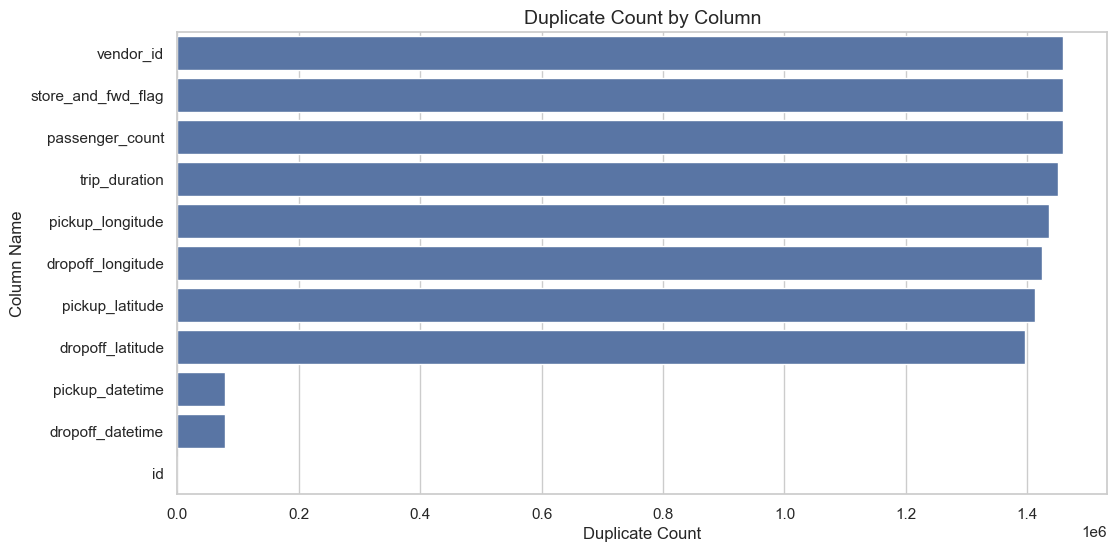

In [6]:

dup_summary = summary_df[["column_name", "duplicate_count", "duplicate_percentage"]].copy()
dup_summary = dup_summary.sort_values(by="duplicate_count", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=dup_summary,
    x="duplicate_count",
    y="column_name"
)

plt.title("Duplicate Count by Column")
plt.xlabel("Duplicate Count")
plt.ylabel("Column Name")
plt.show()

# 2. 🧩 Feature Extraction & Feature Type Classification

In this section, we will identify different types of features from the NYC Taxi Trip dataset before detailed EDA.

---

## 🔢 Numeric Features

### 📏 Continuous Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`
- `trip_duration` 🎯 Target variable

### 👥 Count / Discrete Numeric Features
- `passenger_count`

### 🔢 Ordinal Numeric Features
- No direct ordinal numeric feature found in this dataset

### ⏰ Temporal Numeric Features  
Features that can be extracted from datetime columns:

From `pickup_datetime`:
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `pickup_dayofweek`
- `pickup_weekend`
- `pickup_minute`

From `dropoff_datetime`:
- `dropoff_hour`
- `dropoff_day`
- `dropoff_month`
- `dropoff_dayofweek`

---

## 🏷️ Categorical Features

### 🧾 Nominal Categorical Features
- `vendor_id`

### 🔁 Binary Categorical Features
- `store_and_fwd_flag`

### 📊 Ordinal Categorical Features
- No direct ordinal categorical feature found in this dataset

---

## 🆔 Identifier Feature

### Unique ID
- `id`

This column is mainly used for identifying each trip and is usually not used directly for analysis or modeling.

---

## 🎯 Target Feature

### Prediction Target
- `trip_duration`

This is the main target variable for the NYC Taxi Trip Duration prediction project.

# 3. 🎯 Target Variable Analysis — Trip Duration

In this section, we will analyze the target variable `trip_duration`, which represents the total duration of each taxi trip.  
We will check its basic statistics, distribution pattern, skewness, outliers, and possible transformation needs.  
This step is important because the target variable directly affects model learning and prediction performance.

## 3.1 📌 Basic Summary Statistics of Target Variable

In this step, we will check the basic statistical information of the target variable `trip_duration`.  
This helps us understand the central value, spread, minimum-maximum range, and overall behavior of the target column.

In [7]:
target_col = "trip_duration"

# Safety check
if target_col not in train.columns:
    raise ValueError(f"'{target_col}' column not found in train dataframe.")

target = train[target_col]

# Mode handling
mode_values = target.mode()
mode_value = mode_values.iloc[0] if len(mode_values) > 0 else np.nan

# Basic summary dictionary
target_summary = {
    "Total Count": target.count(),
    "Data Type": target.dtype,
    "Missing Count": target.isnull().sum(),
    "Missing Percentage (%)": round((target.isnull().sum() / len(train)) * 100, 2),
    "Unique Values": target.nunique(),
    "Minimum": target.min(),
    "Maximum": target.max(),
    "Range": target.max() - target.min(),
    "Mean": target.mean(),
    "Median": target.median(),
    "Mode": mode_value,
    "Standard Deviation": target.std(),
    "Variance": target.var(),
    "Skewness": target.skew(),
    "Kurtosis": target.kurtosis(),
    "25th Percentile (Q1)": target.quantile(0.25),
    "50th Percentile (Q2 / Median)": target.quantile(0.50),
    "75th Percentile (Q3)": target.quantile(0.75)
}

# Create dataframe
target_summary_df = pd.DataFrame({
    "Metric": target_summary.keys(),
    "Value": target_summary.values()
})

# Improve display formatting
target_summary_df["Value"] = target_summary_df["Value"].apply(
    lambda x: round(x, 4) if isinstance(x, (int, float, np.integer, np.floating)) else x
)

# Display summary dataframe
target_summary_df

,Metric,Value
0,Total Count,1458644
1,Data Type,int64
2,Missing Count,0
3,Missing Percentage (%),0.0000
4,Unique Values,7417
5,Minimum,1
6,Maximum,3526282
7,Range,3526281
8,Mean,959.4923
9,Median,662.0000


In [8]:
target_summary_df.to_csv("temporal.csv")

### 📝 Summary of Target Variable Basic Statistics

- The dataset contains **1,458,644 trip records** for the target variable `trip_duration`.
- There are **no missing values**, so the target column is complete.
- The minimum trip duration is **1 second**, which may indicate very short or abnormal trips.
- The maximum trip duration is **3,526,282 seconds**, which is extremely large and likely an outlier.
- The mean trip duration is **959.49 seconds**, about **15.99 minutes**.
- The median trip duration is **662 seconds**, about **11.03 minutes**.
- The mode is **368 seconds**, about **6.13 minutes**.
- The mean is higher than the median, which indicates a **right-skewed distribution**.
- The skewness value is **343.16**, showing that the target variable is **highly positively skewed**.
- The kurtosis value is **192,131.52**, which indicates the presence of **extreme outliers**.
- The middle 50% of trips are between **397 seconds** and **1075 seconds**.
- In minutes, most normal trips are roughly between **6.62 minutes** and **17.92 minutes**.
- Outlier analysis and log transformation will be very important before modeling.

## 3.2 🧹 Data Quality Check of Target Variable

In this step, we will check the target variable `trip_duration` for possible data quality issues.  
We will focus on missing values, zero or negative duration, duplicate target values, very small trips, very large trips, and invalid trip duration records.

In [9]:
### 3.2.1 🎯 Select Target Variable

target_col = "trip_duration"

if target_col not in train.columns:
    raise ValueError(f"{target_col} column not found in train dataframe.")

target = train[target_col]
total_rows = len(train)

print("Target Column:", target_col)
print("Total Rows:", total_rows)

Target Column: trip_duration
Total Rows: 1458644


In [10]:
### 3.2.2 🧩 Missing Value Check

missing_count = target.isnull().sum()
missing_percentage = (missing_count / total_rows) * 100

missing_df = pd.DataFrame({
    "Check": ["Missing Values"],
    "Count": [missing_count],
    "Percentage (%)": [round(missing_percentage, 4)]
})

missing_df

,Check,Count,Percentage (%)
0,Missing Values,0,0.0000


In [11]:
### 3.2.3 🚫 Zero Duration Check

zero_count = (target == 0).sum()
zero_percentage = (zero_count / total_rows) * 100

zero_df = pd.DataFrame({
    "Check": ["Zero Duration Values"],
    "Condition": ["trip_duration == 0"],
    "Count": [zero_count],
    "Percentage (%)": [round(zero_percentage, 4)]
})

zero_df

,Check,Condition,Count,Percentage (%)
0,Zero Duration Values,trip_duration == 0,0,0.0000


In [12]:
### 3.2.4 ⛔ Negative Duration Check

negative_count = (target < 0).sum()
negative_percentage = (negative_count / total_rows) * 100

negative_df = pd.DataFrame({
    "Check": ["Negative Duration Values"],
    "Condition": ["trip_duration < 0"],
    "Count": [negative_count],
    "Percentage (%)": [round(negative_percentage, 4)]
})

negative_df

,Check,Condition,Count,Percentage (%)
0,Negative Duration Values,trip_duration < 0,0,0.0000


In [13]:
### 3.2.5 🔁 Duplicate Values Inside Target Column

duplicate_count = target.duplicated().sum()
duplicate_percentage = (duplicate_count / total_rows) * 100

duplicate_target_df = pd.DataFrame({
    "Check": ["Duplicate Values Inside Target Column"],
    "Count": [duplicate_count],
    "Percentage (%)": [round(duplicate_percentage, 4)]
})

duplicate_target_df

,Check,Count,Percentage (%)
0,Duplicate Values Inside Target Column,1451227,99.4915


In [14]:
### 3.2.6 ⏱️ Extremely Small Duration Check

small_duration_threshold = 60   # less than 1 minute

small_duration_count = ((target > 0) & (target < small_duration_threshold)).sum()
small_duration_percentage = (small_duration_count / total_rows) * 100

small_duration_df = pd.DataFrame({
    "Check": ["Extremely Small Duration Values"],
    "Condition": [f"0 < trip_duration < {small_duration_threshold} seconds"],
    "Count": [small_duration_count],
    "Percentage (%)": [round(small_duration_percentage, 4)]
})

small_duration_df

,Check,Condition,Count,Percentage (%)
0,Extremely Small Duration Values,0 < trip_duration < 60 seconds,8595,0.5892


In [15]:
### 3.2.7 🕒 Extremely Large Duration Check

large_duration_threshold = 6 * 3600   # more than 6 hours

large_duration_count = (target > large_duration_threshold).sum()
large_duration_percentage = (large_duration_count / total_rows) * 100

large_duration_df = pd.DataFrame({
    "Check": ["Extremely Large Duration Values"],
    "Condition": [f"trip_duration > {large_duration_threshold} seconds"],
    "Threshold in Hours": [large_duration_threshold / 3600],
    "Count": [large_duration_count],
    "Percentage (%)": [round(large_duration_percentage, 4)]
})

large_duration_df

,Check,Condition,Threshold in Hours,Count,Percentage (%)
0,Extremely Large Duration Values,trip_duration > 21600 seconds,6.0000,2061,0.1413


In [16]:
### 3.2.8 ⚠️ Invalid Trip Duration Check

invalid_duration_threshold = 24 * 3600   # more than 24 hours

invalid_duration_count = (
    target.isnull() |
    (target <= 0) |
    (target > invalid_duration_threshold)
).sum()

invalid_duration_percentage = (invalid_duration_count / total_rows) * 100

invalid_duration_df = pd.DataFrame({
    "Check": ["Invalid Trip Duration Values"],
    "Condition": ["trip_duration is missing OR <= 0 OR > 24 hours"],
    "Count": [invalid_duration_count],
    "Percentage (%)": [round(invalid_duration_percentage, 4)]
})

invalid_duration_df

,Check,Condition,Count,Percentage (%)
0,Invalid Trip Duration Values,trip_duration is missing OR <= 0 OR > 24 hours,4,0.0003


In [17]:
### 3.2.9 📊 Final Target Data Quality Summary

target_quality_summary_df = pd.concat(
    [
        missing_df,
        zero_df[["Check", "Count", "Percentage (%)"]],
        negative_df[["Check", "Count", "Percentage (%)"]],
        duplicate_target_df,
        small_duration_df[["Check", "Count", "Percentage (%)"]],
        large_duration_df[["Check", "Count", "Percentage (%)"]],
        invalid_duration_df[["Check", "Count", "Percentage (%)"]]
    ],
    ignore_index=True
)

target_quality_summary_df

,Check,Count,Percentage (%)
0,Missing Values,0,0.0000
1,Zero Duration Values,0,0.0000
2,Negative Duration Values,0,0.0000
3,Duplicate Values Inside Target Column,1451227,99.4915
4,Extremely Small Duration Values,8595,0.5892
5,Extremely Large Duration Values,2061,0.1413
6,Invalid Trip Duration Values,4,0.0003


In [18]:
### 3.2.10 🔎 View Suspicious Target Records

suspicious_target_rows = train[
    (target.isnull()) |
    (target <= 0) |
    ((target > 0) & (target < 60)) |
    (target > 24 * 3600)
]

print("Suspicious Target Records:", suspicious_target_rows.shape[0])

suspicious_target_rows.head()

Suspicious Target Records: 8599


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
72,id1510700,2,2016-02-20 21:58:13,2016-02-20 21:59:10,1,-73.9584,40.7726,-73.9551,40.7742,N,57
323,id2954399,1,2016-06-27 11:22:37,2016-06-27 11:23:17,1,-74.0010,40.7567,-74.0010,40.7566,N,40
842,id3263580,2,2016-05-21 12:46:46,2016-05-21 12:46:49,2,-73.7824,40.6488,-73.7824,40.6487,N,3
853,id2730154,2,2016-03-29 22:39:46,2016-03-29 22:40:44,5,-73.9822,40.7318,-73.9799,40.7348,N,58
1107,id0729156,2,2016-06-23 13:36:48,2016-06-23 13:36:50,3,-73.8277,40.7162,-73.8221,40.7115,N,2


In [19]:
### 3.2.11 🎨 Styled Target Data Quality Summary

target_quality_summary_df.style.background_gradient(
    subset=["Count", "Percentage (%)"],
    cmap="Reds"
)

,Check,Count,Percentage (%)
0,Missing Values,0,0.000000
1,Zero Duration Values,0,0.000000
2,Negative Duration Values,0,0.000000
3,Duplicate Values Inside Target Column,1451227,99.491500
4,Extremely Small Duration Values,8595,0.589200
5,Extremely Large Duration Values,2061,0.141300
6,Invalid Trip Duration Values,4,0.000300


In [20]:
suspicious_target_rows.to_csv("temporal_1.csv")

In [21]:
target_quality_summary_df.to_csv("temporal_2.csv")

### 📝 Summary of Target Variable Data Quality Check

- The target variable `trip_duration` has **0 missing values**, so there is no missing data problem in the target column.
- There are **0 zero duration values**, which means no trip has exactly `0` seconds duration.
- There are **0 negative duration values**, so the target column does not contain impossible negative trip durations.
- The target column has **1,451,227 duplicate duration values**, around **99.49%**, but this is **normal** because many taxi trips can have the same duration.
- There are **8,595 extremely small duration values**, around **0.59%**, where trip duration is less than **1 minute**.
- There are **2,061 extremely large duration values**, around **0.14%**, where trip duration is greater than **6 hours**.
- There are only **4 invalid trip duration values**, around **0.0003%**, based on the condition `trip_duration <= 0` or `trip_duration > 24 hours`.
- Overall, the target variable has no missing, zero, or negative value issues.
- However, very small trips and very large trips should be checked carefully because they may contain abnormal or unusual trip records.
- For the next step, outlier analysis is important to decide whether these extreme duration values should be removed, capped, or transformed.

## 3.3 📊 Distribution Analysis of Target Variable

In this section, we will analyze the distribution pattern of `trip_duration`.  
We will use histogram, KDE plot, frequency distribution, log-transformed distribution, and distribution shape checking to understand whether the target variable is normal-like or skewed.

In [22]:
### 3.3.1 🎯 Select Target Variable for Distribution Analysis

target_col = "trip_duration"

target = train[target_col]

print("Target Column:", target_col)
print("Total Values:", len(target))
print("Minimum Duration:", target.min())
print("Maximum Duration:", target.max())

Target Column: trip_duration
Total Values: 1458644
Minimum Duration: 1
Maximum Duration: 3526282


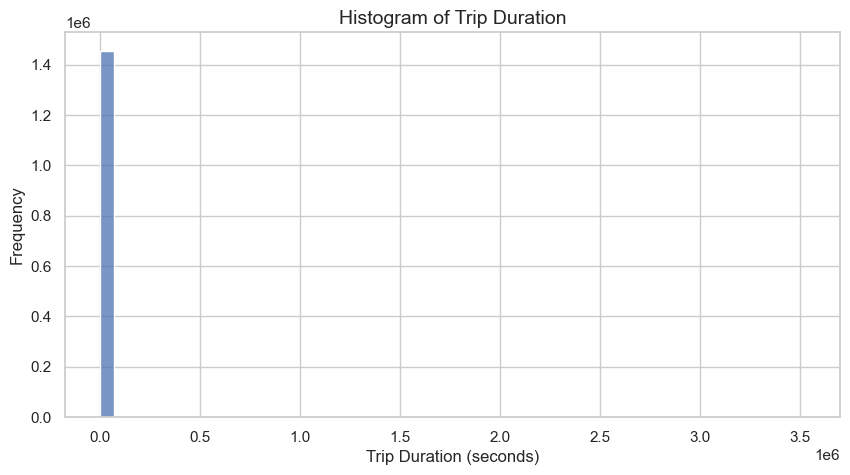

In [23]:
### 3.3.2 📊 Histogram of Trip Duration

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x=target_col,
    bins=50
)

plt.title("Histogram of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

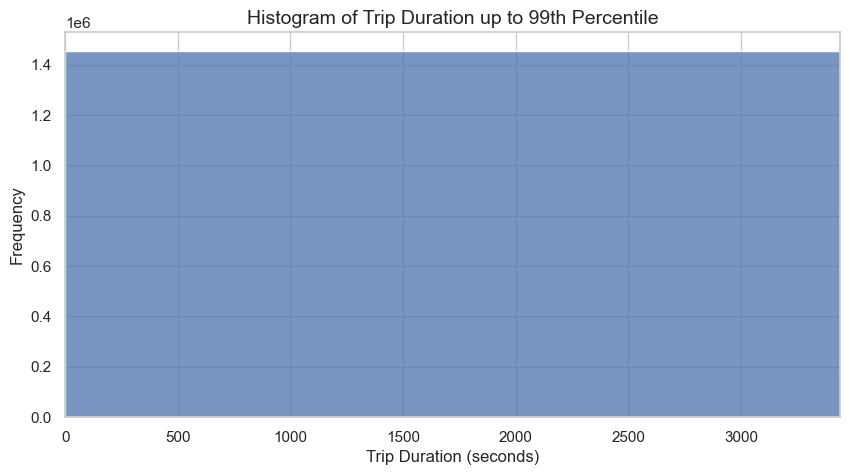

In [24]:
### 3.3.3 📊 Histogram with Limited Range

plt.figure(figsize=(10, 5))

sns.histplot(
    train[target_col],
    bins=50
)

plt.xlim(0, train[target_col].quantile(0.99))

plt.title("Histogram of Trip Duration up to 99th Percentile")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

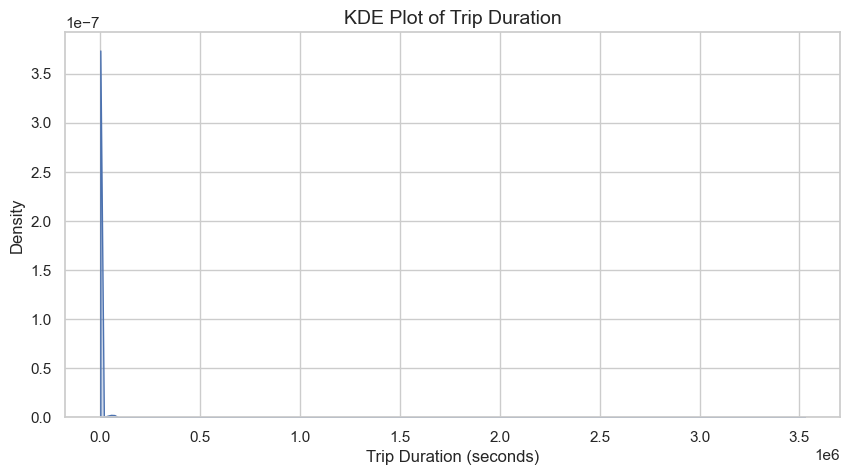

In [25]:
### 3.3.4 🌊 KDE Plot of Trip Duration

plt.figure(figsize=(10, 5))

sns.kdeplot(
    data=train,
    x=target_col,
    fill=True
)

plt.title("KDE Plot of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Density")
plt.show()

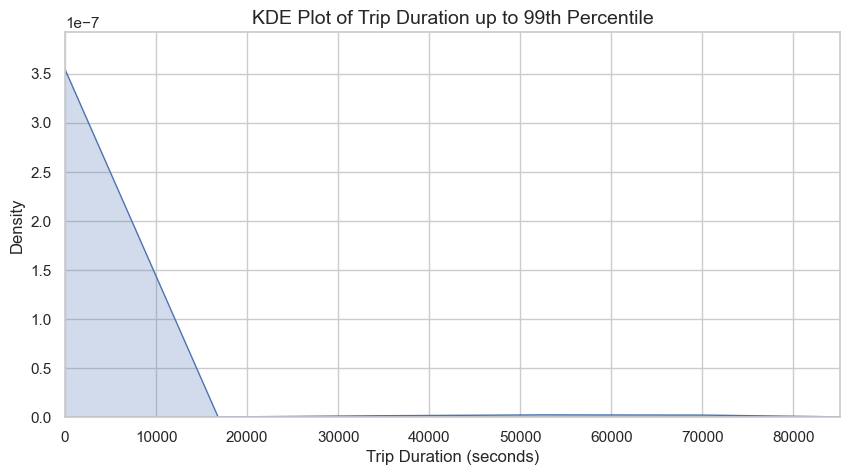

In [26]:
### 3.3.5 🌊 KDE Plot with Limited Range

plt.figure(figsize=(10, 5))

sns.kdeplot(
    train[target_col],
    fill=True
)

plt.xlim(0, train[target_col].quantile(0.999))

plt.title("KDE Plot of Trip Duration up to 99th Percentile")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Density")
plt.show()

In [27]:
### 3.3.6 📋 Frequency Distribution Table

frequency_df = train[target_col].value_counts().reset_index()

frequency_df.columns = ["trip_duration", "frequency"]

frequency_df = frequency_df.sort_values(
    by="frequency",
    ascending=False
).reset_index(drop=True)

frequency_df

,trip_duration,frequency
0,368,1624
1,408,1584
2,348,1582
3,367,1581
4,358,1577
...,...,...
7412,85163,1
7413,85484,1
7414,85537,1
7415,8351,1


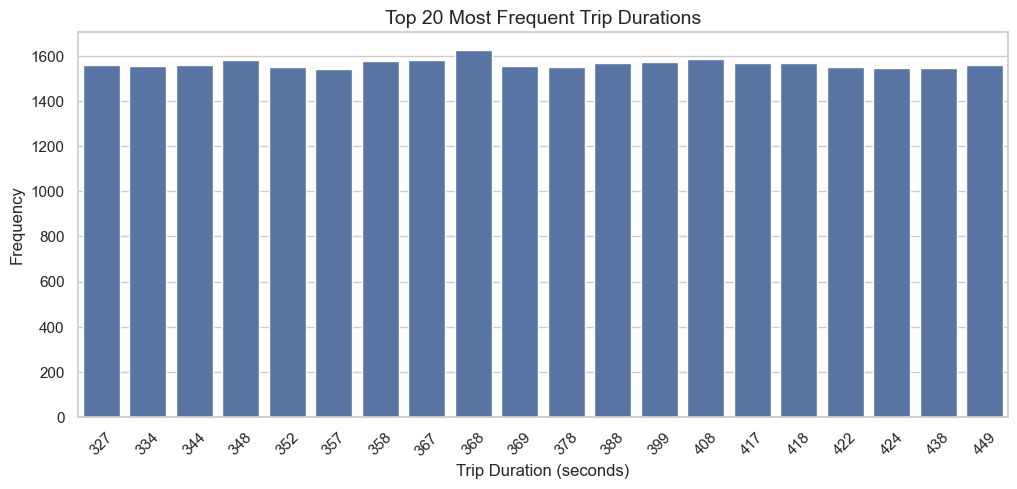

In [28]:
### 3.3.7 🔝 Top 20 Most Frequent Trip Durations

top_20_frequency = frequency_df.head(20)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_20_frequency,
    x="trip_duration",
    y="frequency"
)

plt.title("Top 20 Most Frequent Trip Durations")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [29]:
### 3.3.8 🔄 Create Log-Transformed Target Variable

train["log_trip_duration"] = np.log1p(train[target_col])

print("Original Target:", target_col)
print("Log Transformed Target: log_trip_duration")

train[[target_col, "log_trip_duration"]].head()

Original Target: trip_duration
Log Transformed Target: log_trip_duration


,trip_duration,log_trip_duration
0,455,6.1225
1,663,6.4983
2,2124,7.6615
3,429,6.0638
4,435,6.0776


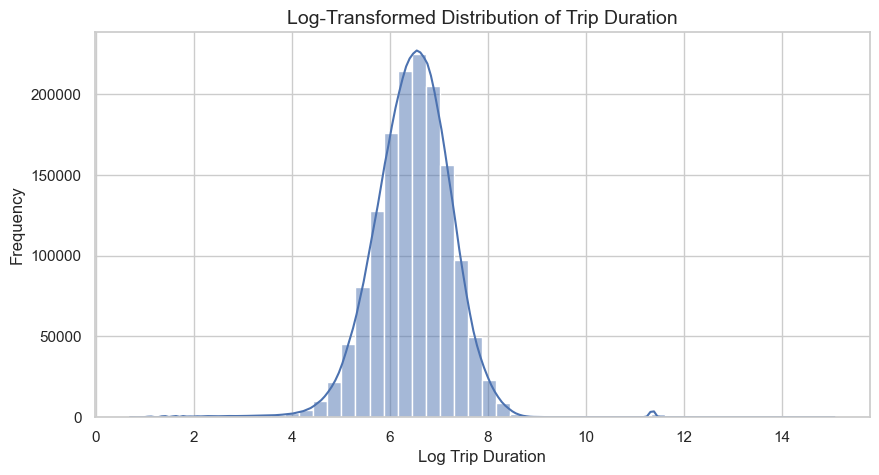

In [30]:
### 3.3.9 📊 Log-Transformed Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x="log_trip_duration",
    bins=50,
    kde=True
)

plt.title("Log-Transformed Distribution of Trip Duration")
plt.xlabel("Log Trip Duration")
plt.ylabel("Frequency")
plt.show()

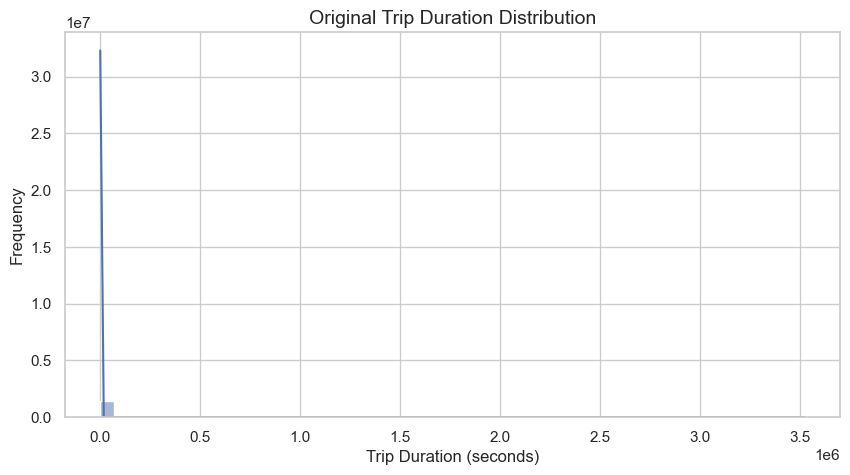

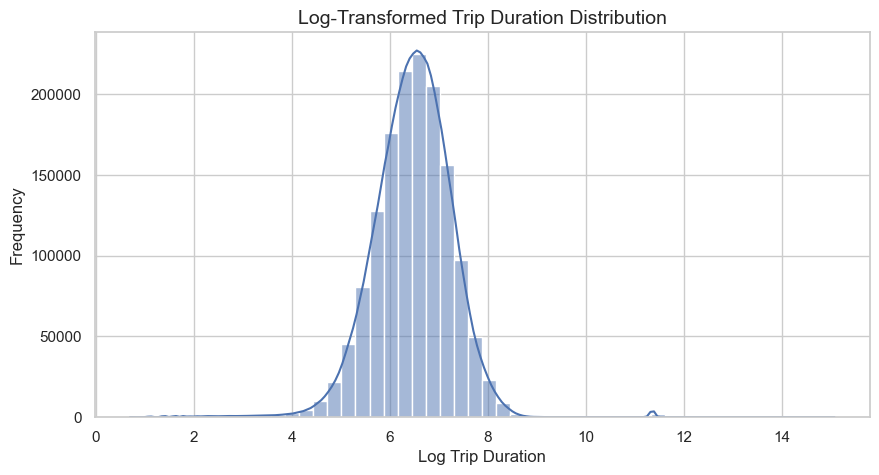

In [31]:
### 3.3.10 📊 Original vs Log-Transformed Distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    train[target_col],
    bins=50,
    kde=True
)


plt.title("Original Trip Duration Distribution")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(10, 5))

sns.histplot(
    train["log_trip_duration"],
    bins=50,
    kde=True
)

plt.title("Log-Transformed Trip Duration Distribution")
plt.xlabel("Log Trip Duration")
plt.ylabel("Frequency")
plt.show()

In [32]:
### 3.3.11 📐 Distribution Shape Checking

mean_value = train[target_col].mean()
median_value = train[target_col].median()
mode_value = train[target_col].mode()[0]

skewness_value = train[target_col].skew()
kurtosis_value = train[target_col].kurtosis()

distribution_shape_df = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Mode",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        mean_value,
        median_value,
        mode_value,
        skewness_value,
        kurtosis_value
    ]
})

distribution_shape_df["Value"] = distribution_shape_df["Value"].round(4)

distribution_shape_df

,Metric,Value
0,Mean,959.4923
1,Median,662.0000
2,Mode,368.0000
3,Skewness,343.1639
4,Kurtosis,192131.5173


In [33]:
### 3.3.12 🧠 Automatic Skewness Interpretation

if skewness_value > 1:
    shape = "Highly Right-Skewed"
elif skewness_value > 0.5:
    shape = "Moderately Right-Skewed"
elif skewness_value < -1:
    shape = "Highly Left-Skewed"
elif skewness_value < -0.5:
    shape = "Moderately Left-Skewed"
else:
    shape = "Approximately Symmetric / Normal-like"

shape_df = pd.DataFrame({
    "Target Variable": [target_col],
    "Skewness": [round(skewness_value, 4)],
    "Distribution Shape": [shape]
})

shape_df

,Target Variable,Skewness,Distribution Shape
0,trip_duration,343.1639,Highly Right-Skewed


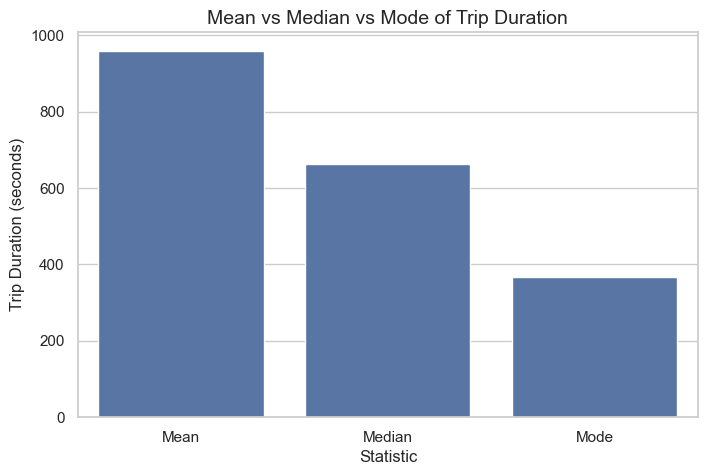

In [34]:
### 3.3.13 📊 Mean vs Median Visualization

mean_median_df = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode"],
    "Value": [mean_value, median_value, mode_value]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=mean_median_df,
    x="Statistic",
    y="Value"
)

plt.title("Mean vs Median vs Mode of Trip Duration")
plt.xlabel("Statistic")
plt.ylabel("Trip Duration (seconds)")
plt.show()

In [35]:
### 3.3.14 📌 Final Distribution Summary DataFrame

distribution_summary_df = pd.DataFrame({
    "Analysis Point": [
        "Original Distribution",
        "Mean vs Median",
        "Skewness",
        "Kurtosis",
        "Log Transformation"
    ],
    "Finding": [
        "Checked using histogram and KDE plot",
        "Mean is compared with median to detect skewness",
        f"Skewness value is {round(skewness_value, 4)}",
        f"Kurtosis value is {round(kurtosis_value, 4)}",
        "Log transformation was applied using np.log1p()"
    ]
})

distribution_summary_df

,Analysis Point,Finding
0,Original Distribution,Checked using histogram and KDE plot
1,Mean vs Median,Mean is compared with median to detect skewness
2,Skewness,Skewness value is 343.1639
3,Kurtosis,Kurtosis value is 192131.5173
4,Log Transformation,Log transformation was applied using np.log1p()


### 📝 Summary of Target Variable Distribution Analysis

- The original `trip_duration` distribution is **highly right-skewed**.
- Most trip duration values are concentrated near the lower range, but a few extremely large values stretch the graph to the right.
- Because of extreme high values, the original histogram looks compressed near zero.
- The log-transformed distribution is much clearer and more balanced than the original distribution.
- After applying `log1p(trip_duration)`, the distribution becomes close to a normal-like bell shape.
- The log-transformed plot shows that most trips are concentrated around the middle duration range.
- A small separate peak in the far right side of the log plot indicates the presence of some extremely long-duration trips.
- The mean trip duration is higher than the median and mode.
- Mean ≈ **959 seconds**, median ≈ **662 seconds**, and mode ≈ **368 seconds**.
- Since `Mean > Median > Mode`, the target variable has a **positive/right-skewed distribution**.
- This confirms that some very long trips are pulling the average duration upward.
- For modeling, using `log_trip_duration` can be more useful than using raw `trip_duration`.
- Outlier analysis is needed next to identify extremely short and extremely long trip records.

## 3.4 📦 Outlier Analysis of Target Variable

In this section, we will detect outliers in `trip_duration` using the IQR method.  
We will calculate Q1, Q3, IQR, lower bound, upper bound, outlier count, and outlier percentage.  
Finally, we will check how the distribution looks after outlier handling.

In [36]:
### 3.4.1 📌 IQR-Based Outlier Summary

target_col = "trip_duration"
target = train[target_col]
total_rows = len(train)

# IQR calculation
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outlier masks
lower_outlier_mask = target < lower_bound
upper_outlier_mask = target > upper_bound
outlier_mask = lower_outlier_mask | upper_outlier_mask

# Counts
lower_outlier_count = lower_outlier_mask.sum()
upper_outlier_count = upper_outlier_mask.sum()
total_outlier_count = outlier_mask.sum()

# Percentages
lower_outlier_percentage = (lower_outlier_count / total_rows) * 100
upper_outlier_percentage = (upper_outlier_count / total_rows) * 100
total_outlier_percentage = (total_outlier_count / total_rows) * 100

# Summary dataframe
outlier_summary_df = pd.DataFrame({
    "Metric": [
        "Q1 - 25th Percentile",
        "Q3 - 75th Percentile",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Lower Outlier Count",
        "Upper Outlier Count",
        "Total Outlier Count",
        "Lower Outlier Percentage (%)",
        "Upper Outlier Percentage (%)",
        "Total Outlier Percentage (%)"
    ],
    "Value": [
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        lower_outlier_count,
        upper_outlier_count,
        total_outlier_count,
        lower_outlier_percentage,
        upper_outlier_percentage,
        total_outlier_percentage
    ]
})

outlier_summary_df["Value"] = outlier_summary_df["Value"].round(4)

outlier_summary_df

,Metric,Value
0,Q1 - 25th Percentile,397.0000
1,Q3 - 75th Percentile,1075.0000
2,IQR,678.0000
3,Lower Bound,-620.0000
4,Upper Bound,2092.0000
5,Lower Outlier Count,0.0000
6,Upper Outlier Count,74220.0000
7,Total Outlier Count,74220.0000
8,Lower Outlier Percentage (%),0.0000
9,Upper Outlier Percentage (%),5.0883


In [37]:
### 3.4.2 🔎 Extreme Lower & Upper Duration Values

display_cols = [col for col in ["id", "pickup_datetime", "dropoff_datetime", target_col] if col in train.columns]

extreme_lower_values = train[display_cols].sort_values(by=target_col, ascending=True).head(10)
extreme_upper_values = train[display_cols].sort_values(by=target_col, ascending=False).head(10)

print("Extreme Lower Duration Values:")
display(extreme_lower_values)

print("Extreme Upper Duration Values:")
display(extreme_upper_values)

Extreme Lower Duration Values:


,id,pickup_datetime,dropoff_datetime,trip_duration
1306890,id2608913,2016-03-12 02:15:31,2016-03-12 02:15:32,1
1063496,id3712815,2016-06-20 20:16:17,2016-06-20 20:16:18,1
810851,id1250016,2016-03-03 17:02:47,2016-03-03 17:02:48,1
1382872,id0839864,2016-02-06 13:40:27,2016-02-06 13:40:28,1
451396,id2836747,2016-01-26 10:47:22,2016-01-26 10:47:23,1
600247,id2517984,2016-01-09 00:28:55,2016-01-09 00:28:56,1
1439166,id2943073,2016-01-03 16:55:44,2016-01-03 16:55:45,1
35196,id2536510,2016-04-17 11:44:49,2016-04-17 11:44:50,1
610159,id0578509,2016-02-03 12:35:22,2016-02-03 12:35:23,1
1029695,id2115750,2016-04-22 16:00:22,2016-04-22 16:00:23,1


Extreme Upper Duration Values:


,id,pickup_datetime,dropoff_datetime,trip_duration
978383,id0053347,2016-02-13 22:46:52,2016-03-25 18:18:14,3526282
924150,id1325766,2016-01-05 06:14:15,2016-01-31 01:01:07,2227612
680594,id0369307,2016-02-13 22:38:00,2016-03-08 15:57:38,2049578
355003,id1864733,2016-01-05 00:19:42,2016-01-27 11:08:38,1939736
1234291,id1942836,2016-02-15 23:18:06,2016-02-16 23:17:58,86392
295382,id0593332,2016-05-31 13:00:39,2016-06-01 13:00:30,86391
73816,id0953667,2016-05-06 00:00:10,2016-05-07 00:00:00,86390
59891,id2837671,2016-06-30 16:37:52,2016-07-01 16:37:39,86387
1360439,id1358458,2016-06-23 16:01:45,2016-06-24 16:01:30,86385
753765,id2589925,2016-05-17 22:22:56,2016-05-18 22:22:35,86379


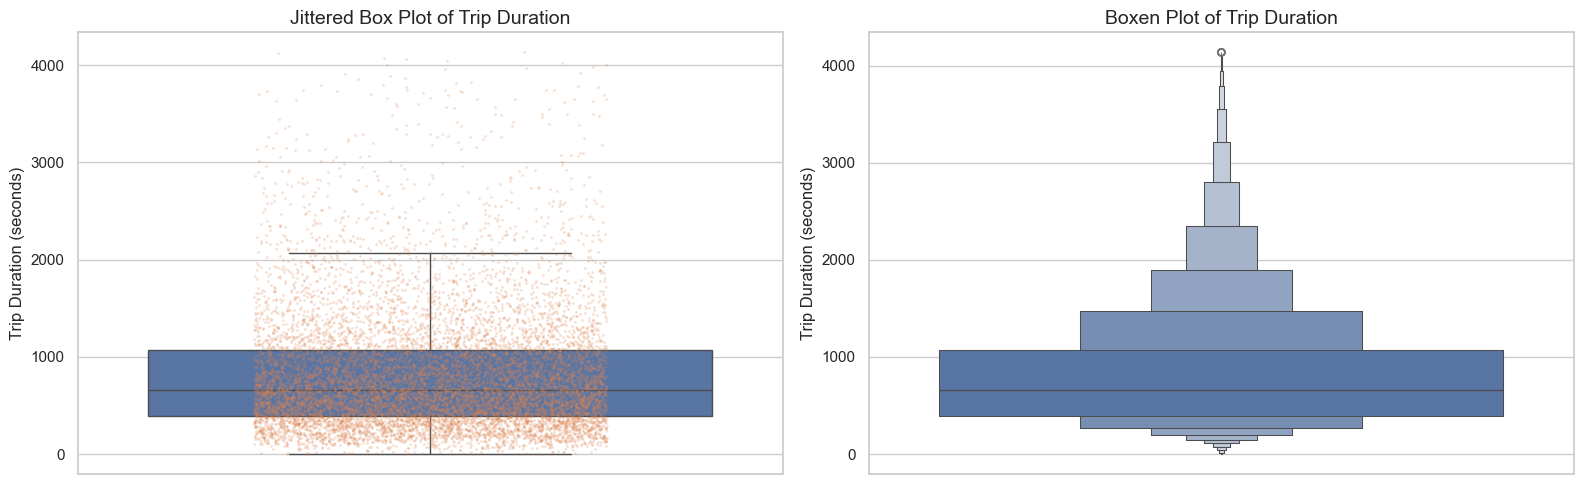

In [38]:
### 3.4.3 📊 Jittered Box Plot & Boxen Plot

# For better visualization only, limit extreme display range
visual_upper_limit = target.quantile(0.995)

visual_data = train[train[target_col] <= visual_upper_limit][[target_col]].copy()

# Sample for jitter plot to avoid heavy plotting
sample_size = min(10000, len(visual_data))
jitter_sample = visual_data.sample(sample_size, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Jittered Box Plot
sns.boxplot(
    data=visual_data,
    y=target_col,
    ax=axes[0],
    showfliers=False
)

sns.stripplot(
    data=jitter_sample,
    y=target_col,
    ax=axes[0],
    jitter=0.25,
    size=2,
    alpha=0.25
)

axes[0].set_title("Jittered Box Plot of Trip Duration")
axes[0].set_ylabel("Trip Duration (seconds)")

# 2. Boxen Plot
sns.boxenplot(
    data=visual_data,
    y=target_col,
    ax=axes[1]
)

axes[1].set_title("Boxen Plot of Trip Duration")
axes[1].set_ylabel("Trip Duration (seconds)")

plt.tight_layout()
plt.show()

In [39]:
### 3.4.4 🧹 Create Outlier-Handled Target Using IQR Filtering

# IQR-based filtering
target_iqr_handled = target[(target >= lower_bound) & (target <= upper_bound)]

outlier_handling_df = pd.DataFrame({
    "Stage": [
        "Original Target",
        "After IQR Outlier Handling",
        "Removed as Outliers"
    ],
    "Row Count": [
        len(target),
        len(target_iqr_handled),
        len(target) - len(target_iqr_handled)
    ],
    "Percentage (%)": [
        100,
        (len(target_iqr_handled) / len(target)) * 100,
        ((len(target) - len(target_iqr_handled)) / len(target)) * 100
    ]
})

outlier_handling_df["Percentage (%)"] = outlier_handling_df["Percentage (%)"].round(4)

outlier_handling_df

,Stage,Row Count,Percentage (%)
0,Original Target,1458644,100.0000
1,After IQR Outlier Handling,1384424,94.9117
2,Removed as Outliers,74220,5.0883


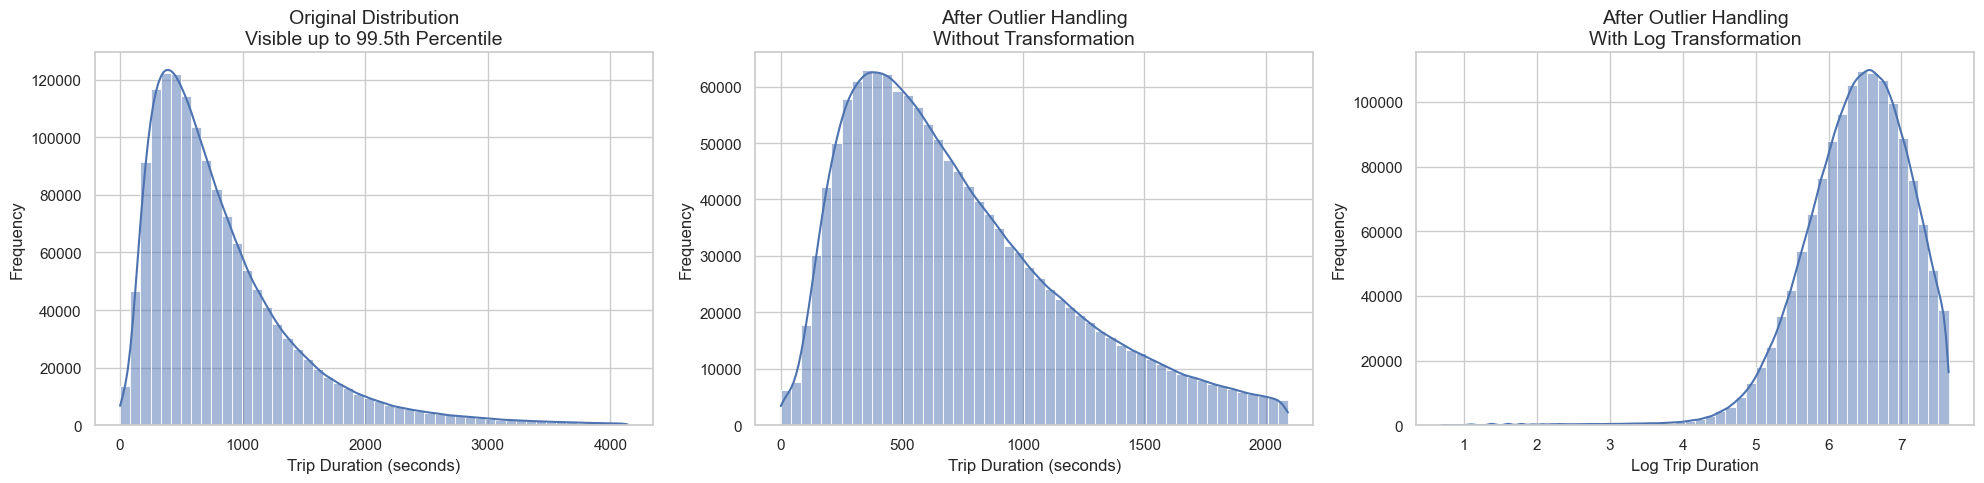

In [40]:
### 3.4.5 📊 Distribution Check Before & After Outlier Handling

log_target_iqr_handled = np.log1p(target_iqr_handled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Original distribution
sns.histplot(
    target[target <= target.quantile(0.995)],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Distribution\nVisible up to 99.5th Percentile")
axes[0].set_xlabel("Trip Duration (seconds)")
axes[0].set_ylabel("Frequency")

# 2. Outlier-handled distribution without transformation
sns.histplot(
    target_iqr_handled,
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("After Outlier Handling\nWithout Transformation")
axes[1].set_xlabel("Trip Duration (seconds)")
axes[1].set_ylabel("Frequency")

# 3. Outlier-handled distribution with log transformation
sns.histplot(
    log_target_iqr_handled,
    bins=50,
    kde=True,
    ax=axes[2]
)

axes[2].set_title("After Outlier Handling\nWith Log Transformation")
axes[2].set_xlabel("Log Trip Duration")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [41]:
### 3.4.6 📌 Distribution Statistics Before & After Outlier Handling

comparison_df = pd.DataFrame({
    "Version": [
        "Original Target",
        "IQR Outlier Handled",
        "IQR Handled + Log Transform"
    ],
    "Mean": [
        target.mean(),
        target_iqr_handled.mean(),
        log_target_iqr_handled.mean()
    ],
    "Median": [
        target.median(),
        target_iqr_handled.median(),
        log_target_iqr_handled.median()
    ],
    "Min": [
        target.min(),
        target_iqr_handled.min(),
        log_target_iqr_handled.min()
    ],
    "Max": [
        target.max(),
        target_iqr_handled.max(),
        log_target_iqr_handled.max()
    ],
    "Skewness": [
        target.skew(),
        target_iqr_handled.skew(),
        log_target_iqr_handled.skew()
    ],
    "Kurtosis": [
        target.kurtosis(),
        target_iqr_handled.kurtosis(),
        log_target_iqr_handled.kurtosis()
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Version,Mean,Median,Min,Max,Skewness,Kurtosis
0,Original Target,959.4923,662.0000,1.0000,3526282.0000,343.1639,192131.5173
1,IQR Outlier Handled,731.7026,632.0000,1.0000,2092.0000,0.8609,0.1315
2,IQR Handled + Log Transform,6.3836,6.4505,0.6931,7.6464,-1.0220,3.2551


### 📝 Summary of Target Variable Outlier Analysis

- Using the IQR method, `Q1 = 397 seconds` and `Q3 = 1075 seconds`.
- The `IQR = 678 seconds`, which represents the spread of the middle 50% trip durations.
- The calculated lower bound is `-620 seconds`, but trip duration cannot be negative.
- Therefore, there are **0 lower outliers** based on the IQR method.
- The upper bound is `2092 seconds`, around **34.87 minutes**.
- Any trip duration greater than `2092 seconds` is considered an upper outlier by the IQR rule.
- Total outliers found: **74,220 records**, around **5.09%** of the dataset.
- All detected outliers are upper outliers, which confirms that `trip_duration` has a strong right-side tail.
- Extreme lower values show some trips with only **1 second duration**, which may represent abnormal, cancelled, or incorrect records.
- Extreme upper values show very large durations, including values like **3,526,282 seconds**, which are clearly unrealistic for normal taxi trips.
- The original distribution is highly right-skewed because of these extreme long-duration trips.
- After IQR-based outlier handling, the distribution becomes much cleaner and more readable.
- After outlier handling, the maximum duration becomes `2092 seconds`, making the target range more realistic.
- The skewness decreases from **343.16** to **0.86**, which shows a major improvement.
- The kurtosis decreases from **192,131.52** to **0.13**, meaning extreme tail effect is greatly reduced.
- After applying log transformation on the outlier-handled target, the distribution becomes more compact and closer to a normal-like shape.
- However, the log-transformed version becomes slightly left-skewed with skewness around **-1.02**.
- For modeling, the outlier-handled target or log-transformed target can be considered depending on the model type.

✅ Use outlier-handled target without log transformation  
❌ Do not apply log transformation after aggressive IQR outlier handling  
⚠️ Use transformation only if it improves distribution or model performance

## 3.5 📍 Percentile / Quantile Analysis of Target Variable

In this section, we will analyze important percentile values of `trip_duration`.  
Because the raw target contains extreme outliers, percentile visualization will be done mainly on the IQR outlier-handled target.  
This helps us understand how trip durations are distributed across different percentage levels.

In [42]:
### 3.5.1 📌 Create Percentile List

target_col = "trip_duration"
target = train[target_col]

percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]

percentile_labels = [
    "1st Percentile",
    "5th Percentile",
    "10th Percentile",
    "25th Percentile",
    "50th Percentile / Median",
    "75th Percentile",
    "90th Percentile",
    "95th Percentile",
    "99th Percentile",
    "99.5th Percentile",
    "99.9th Percentile"
]

In [43]:
### 3.5.2 📦 Create IQR Outlier-Handled Target

Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

target_iqr_handled = target[
    (target >= lower_bound) &
    (target <= upper_bound)
]

print("Original target size:", len(target))
print("After IQR outlier handling:", len(target_iqr_handled))
print("Upper bound:", upper_bound)

Original target size: 1458644
After IQR outlier handling: 1384424
Upper bound: 2092.0


In [44]:
### 3.5.3 📊 Percentile Table: Original vs Outlier-Handled Target

original_percentile_values = target.quantile(percentiles).values
handled_percentile_values = target_iqr_handled.quantile(percentiles).values

percentile_df = pd.DataFrame({
    "Percentile": percentile_labels,
    "Original Duration (sec)": original_percentile_values,
    "Original Duration (min)": original_percentile_values / 60,
    "After Outlier Handling (sec)": handled_percentile_values,
    "After Outlier Handling (min)": handled_percentile_values / 60
})

percentile_df = percentile_df.round(2)

percentile_df

,Percentile,Original Duration (sec),Original Duration (min),After Outlier Handling (sec),After Outlier Handling (min)
0,1st Percentile,87.0000,1.4500,84.0000,1.4000
1,5th Percentile,180.0000,3.0000,176.0000,2.9300
2,10th Percentile,245.0000,4.0800,239.0000,3.9800
3,25th Percentile,397.0000,6.6200,384.0000,6.4000
4,50th Percentile / Median,662.0000,11.0300,632.0000,10.5300
5,75th Percentile,1075.0000,17.9200,991.0000,16.5200
6,90th Percentile,1634.0000,27.2300,1400.0000,23.3300
7,95th Percentile,2104.0000,35.0700,1645.0000,27.4200
8,99th Percentile,3440.0000,57.3300,1971.0000,32.8500
9,99.5th Percentile,4139.0000,68.9800,2029.0000,33.8200


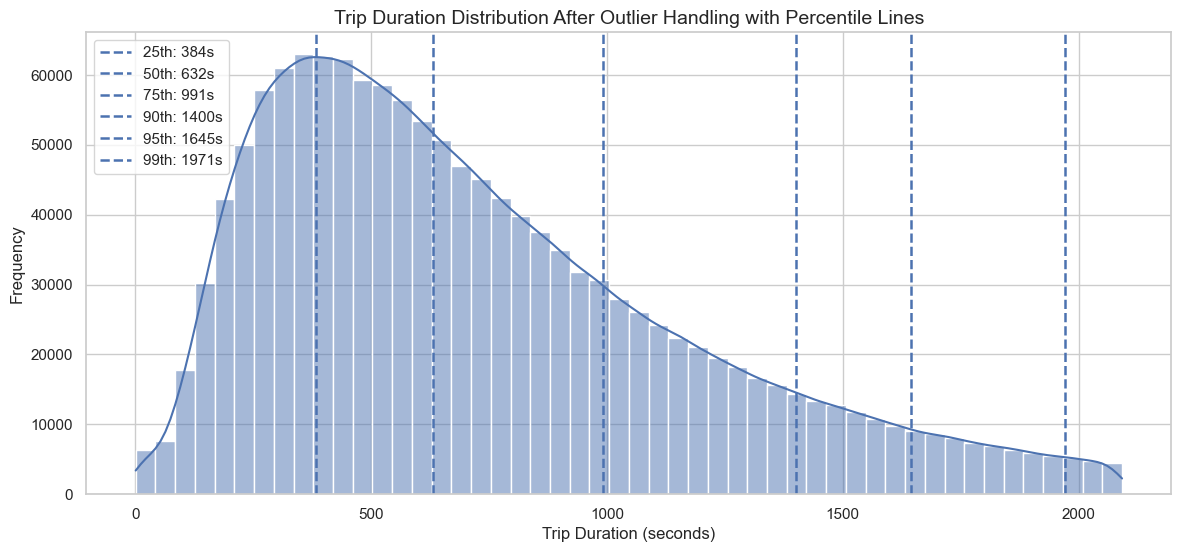

In [45]:
### 3.5.4 📊 Percentile Distribution Plot After Outlier Handling

major_percentiles = {
    "25th": target_iqr_handled.quantile(0.25),
    "50th": target_iqr_handled.quantile(0.50),
    "75th": target_iqr_handled.quantile(0.75),
    "90th": target_iqr_handled.quantile(0.90),
    "95th": target_iqr_handled.quantile(0.95),
    "99th": target_iqr_handled.quantile(0.99)
}

plt.figure(figsize=(14, 6))

sns.histplot(
    target_iqr_handled,
    bins=50,
    kde=True
)

for label, value in major_percentiles.items():
    plt.axvline(
        value,
        linestyle="--",
        linewidth=1.8,
        label=f"{label}: {value:.0f}s"
    )

plt.title("Trip Duration Distribution After Outlier Handling with Percentile Lines")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

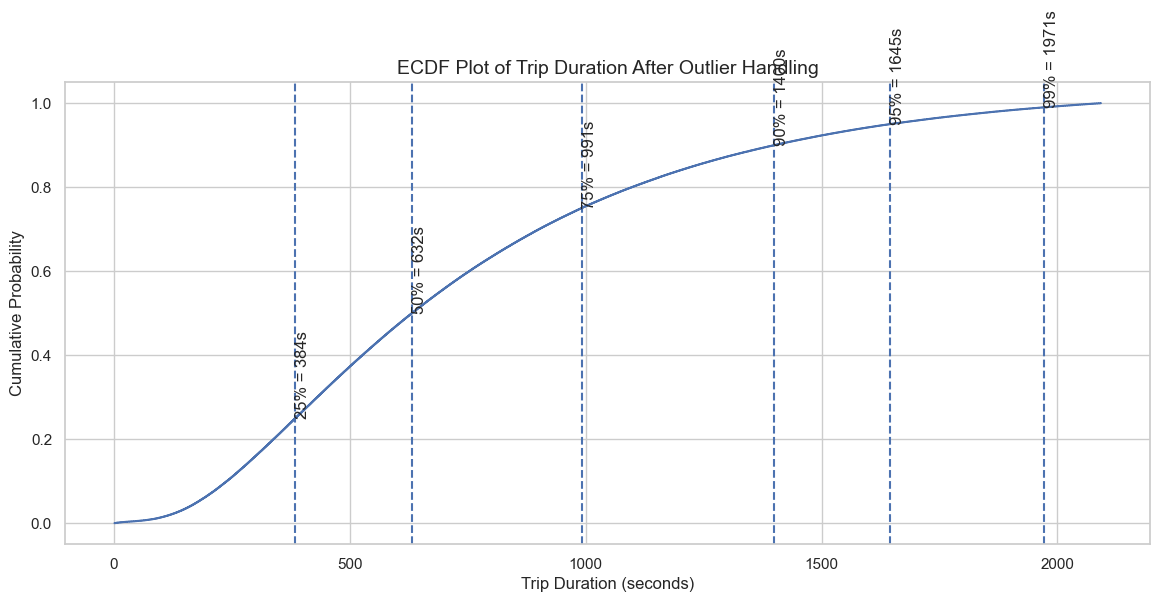

In [46]:
### 3.5.5 📈 ECDF Plot with Percentile Markers

sorted_target = np.sort(target_iqr_handled)
ecdf = np.arange(1, len(sorted_target) + 1) / len(sorted_target)

plt.figure(figsize=(14, 6))

plt.plot(sorted_target, ecdf)

for p in [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    value = target_iqr_handled.quantile(p)
    plt.axvline(value, linestyle="--", linewidth=1.5)
    plt.text(
        value,
        p,
        f"{int(p*100)}% = {value:.0f}s",
        rotation=90,
        verticalalignment="bottom"
    )

plt.title("ECDF Plot of Trip Duration After Outlier Handling")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.show()

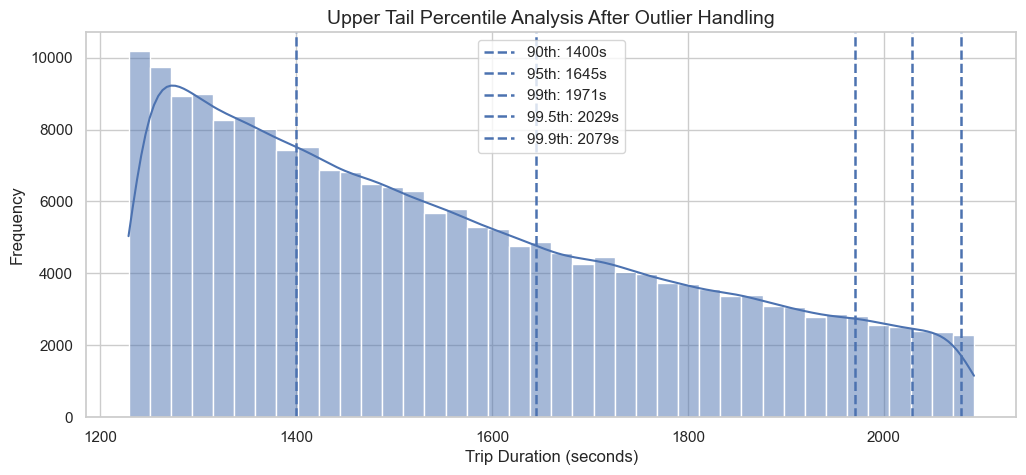

In [47]:
### 3.5.6 🔍 Tail Percentile Zoom Plot

tail_percentiles = {
    "90th": target_iqr_handled.quantile(0.90),
    "95th": target_iqr_handled.quantile(0.95),
    "99th": target_iqr_handled.quantile(0.99),
    "99.5th": target_iqr_handled.quantile(0.995),
    "99.9th": target_iqr_handled.quantile(0.999)
}

plt.figure(figsize=(12, 5))

sns.histplot(
    target_iqr_handled[target_iqr_handled >= target_iqr_handled.quantile(0.85)],
    bins=40,
    kde=True
)

for label, value in tail_percentiles.items():
    plt.axvline(
        value,
        linestyle="--",
        linewidth=1.8,
        label=f"{label}: {value:.0f}s"
    )

plt.title("Upper Tail Percentile Analysis After Outlier Handling")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [48]:
### 3.5.7 📌 Percentile-Based Quick Interpretation Table

interpretation_df = pd.DataFrame({
    "Percentile Range": [
        "Below 25th Percentile",
        "25th to 50th Percentile",
        "50th to 75th Percentile",
        "75th to 90th Percentile",
        "90th to 95th Percentile",
        "95th to 99th Percentile",
        "Above 99th Percentile"
    ],
    "Meaning": [
        "Very short trips",
        "Short trips",
        "Medium trips",
        "Medium to long trips",
        "Long trips",
        "Very long trips",
        "Extreme upper tail trips"
    ]
})

interpretation_df

,Percentile Range,Meaning
0,Below 25th Percentile,Very short trips
1,25th to 50th Percentile,Short trips
2,50th to 75th Percentile,Medium trips
3,75th to 90th Percentile,Medium to long trips
4,90th to 95th Percentile,Long trips
5,95th to 99th Percentile,Very long trips
6,Above 99th Percentile,Extreme upper tail trips


### 📝 Summary of Percentile / Quantile Analysis

- Percentile analysis was done after IQR-based outlier handling because the raw `trip_duration` had extreme values.
- After outlier handling, the distribution becomes easier to understand and percentile lines are clearly visible.
- The 25th percentile is around **384 seconds**, meaning 25% of trips are shorter than about **6.4 minutes**.
- The median / 50th percentile is around **632 seconds**, meaning 50% of trips are shorter than about **10.5 minutes**.
- The 75th percentile is around **991 seconds**, meaning 75% of trips are shorter than about **16.5 minutes**.
- The 90th percentile is around **1400 seconds**, meaning 90% of trips are shorter than about **23.3 minutes**.
- The 95th percentile is around **1645 seconds**, meaning 95% of trips are shorter than about **27.4 minutes**.
- The 99th percentile is around **1971 seconds**, meaning 99% of trips are shorter than about **32.9 minutes**.
- The 99.5th and 99.9th percentiles are close to the upper end of the outlier-handled range.
- The ECDF plot confirms that most trips are concentrated below **1000 seconds**, around **16–17 minutes**.
- The upper-tail plot shows that trips above **1400 seconds** are less frequent and gradually decrease.
- Overall, most NYC taxi trips are short to medium duration trips, while only a small portion are long-duration trips.

## 📝 What We Learned from Target Variable Analysis

So far, from `trip_duration` analysis we understood:

- `trip_duration` has **no missing values**.
- There are **no zero or negative values**, so basic target quality is good.
- Some trips are **extremely small**, like 1 second, which may be abnormal.
- Some trips are **extremely large**, even more than 24 hours, which is not realistic for normal taxi trips.
- Raw `trip_duration` is **highly right-skewed** because of extreme long trips.
- Mean is greater than median and mode, so long-duration trips are pulling the average upward.
- IQR method found many upper outliers.
- After IQR-based outlier handling, the distribution becomes much cleaner.
- After outlier handling, log transformation does not improve the distribution much; it may over-correct the data.
- Percentile analysis shows that most trips are short to medium duration trips.

## 3.7 🔄 Target Transformation Analysis

In this section, we will apply different transformations on the target variable `trip_duration` and compare their effects.  
The main goal is to check whether transformation can reduce skewness, control extreme values, and make the target distribution more stable for modeling.

In [49]:
### 3.7.1 🎯 Prepare Target Variable for Transformation

target_col = "trip_duration"

# Use only valid target values for transformation analysis
# Box-Cox needs strictly positive values
target_clean = train.loc[
    (train[target_col].notnull()) &
    (train[target_col] > 0) &
    (train[target_col] <= 24 * 3600),
    target_col
].copy()

print("Original rows:", len(train))
print("Valid target rows for transformation:", len(target_clean))
print("Removed rows:", len(train) - len(target_clean))
print("Minimum target value:", target_clean.min())
print("Maximum target value:", target_clean.max())

Original rows: 1458644
Valid target rows for transformation: 1458640
Removed rows: 4
Minimum target value: 1
Maximum target value: 86392


In [50]:
### 3.7.2 🔄 Apply Different Target Transformations

from scipy import stats

# Dictionary to store transformations
transformations = {}

# 1. Original
transformations["Original"] = target_clean

# 2. Log Transformation
transformations["Log1p"] = np.log1p(target_clean)

# 3. Natural Log
transformations["Log"] = np.log(target_clean)

# 4. Square Root
transformations["Square Root"] = np.sqrt(target_clean)

# 5. Cube Root
transformations["Cube Root"] = np.cbrt(target_clean)

# 6. Box-Cox Transformation
boxcox_transformed, boxcox_lambda = stats.boxcox(target_clean)
transformations["Box-Cox"] = pd.Series(boxcox_transformed, index=target_clean.index)

# 7. Yeo-Johnson Transformation
yeojohnson_transformed, yeojohnson_lambda = stats.yeojohnson(target_clean)
transformations["Yeo-Johnson"] = pd.Series(yeojohnson_transformed, index=target_clean.index)

print("Box-Cox Lambda:", round(boxcox_lambda, 4))
print("Yeo-Johnson Lambda:", round(yeojohnson_lambda, 4))

Box-Cox Lambda: 0.0555
Yeo-Johnson Lambda: 0.0494


In [51]:
### 3.7.3 📊 Transformation Comparison Summary Table

transformation_summary = []

for name, values in transformations.items():
    transformation_summary.append({
        "Transformation": name,
        "Mean": values.mean(),
        "Median": values.median(),
        "Min": values.min(),
        "Max": values.max(),
        "Std": values.std(),
        "Skewness": values.skew(),
        "Kurtosis": values.kurtosis()
    })

transformation_summary_df = pd.DataFrame(transformation_summary)

# Add simple score: lower is generally better for normal-like shape
transformation_summary_df["Skewness Abs"] = transformation_summary_df["Skewness"].abs()
transformation_summary_df["Kurtosis Abs"] = transformation_summary_df["Kurtosis"].abs()
transformation_summary_df["Shape Score"] = (
    transformation_summary_df["Skewness Abs"] + transformation_summary_df["Kurtosis Abs"]
)

transformation_summary_df = transformation_summary_df.sort_values(
    by="Shape Score",
    ascending=True
).reset_index(drop=True)

transformation_summary_df.round(4)

,Transformation,Mean,Median,Min,Max,Std,Skewness,Kurtosis,Skewness Abs,Kurtosis Abs,Shape Score
0,Log1p,6.4670,6.4968,0.6931,11.3667,0.7956,-0.2932,3.8320,0.2932,3.8320,4.1253
1,Yeo-Johnson,7.6418,7.6615,0.7052,15.2533,1.0922,0.0523,4.1822,0.0523,4.1822,4.2345
2,Log,6.4645,6.4953,0.0000,11.3667,0.7995,-0.3437,4.1477,0.3437,4.1477,4.4914
3,Box-Cox,7.8028,7.8216,0.0000,15.8462,1.1405,0.0624,4.4301,0.0624,4.4301,4.4925
4,Cube Root,8.9365,8.7154,1.0000,44.2070,2.5630,3.7428,46.5253,3.7428,46.5253,50.2680
5,Square Root,27.4738,25.7294,1.0000,293.9252,14.0715,9.2979,166.6568,9.2979,166.6568,175.9547
6,Original,952.8153,662.0000,1.0000,86392.0000,3171.3223,25.2687,666.9675,25.2687,666.9675,692.2362


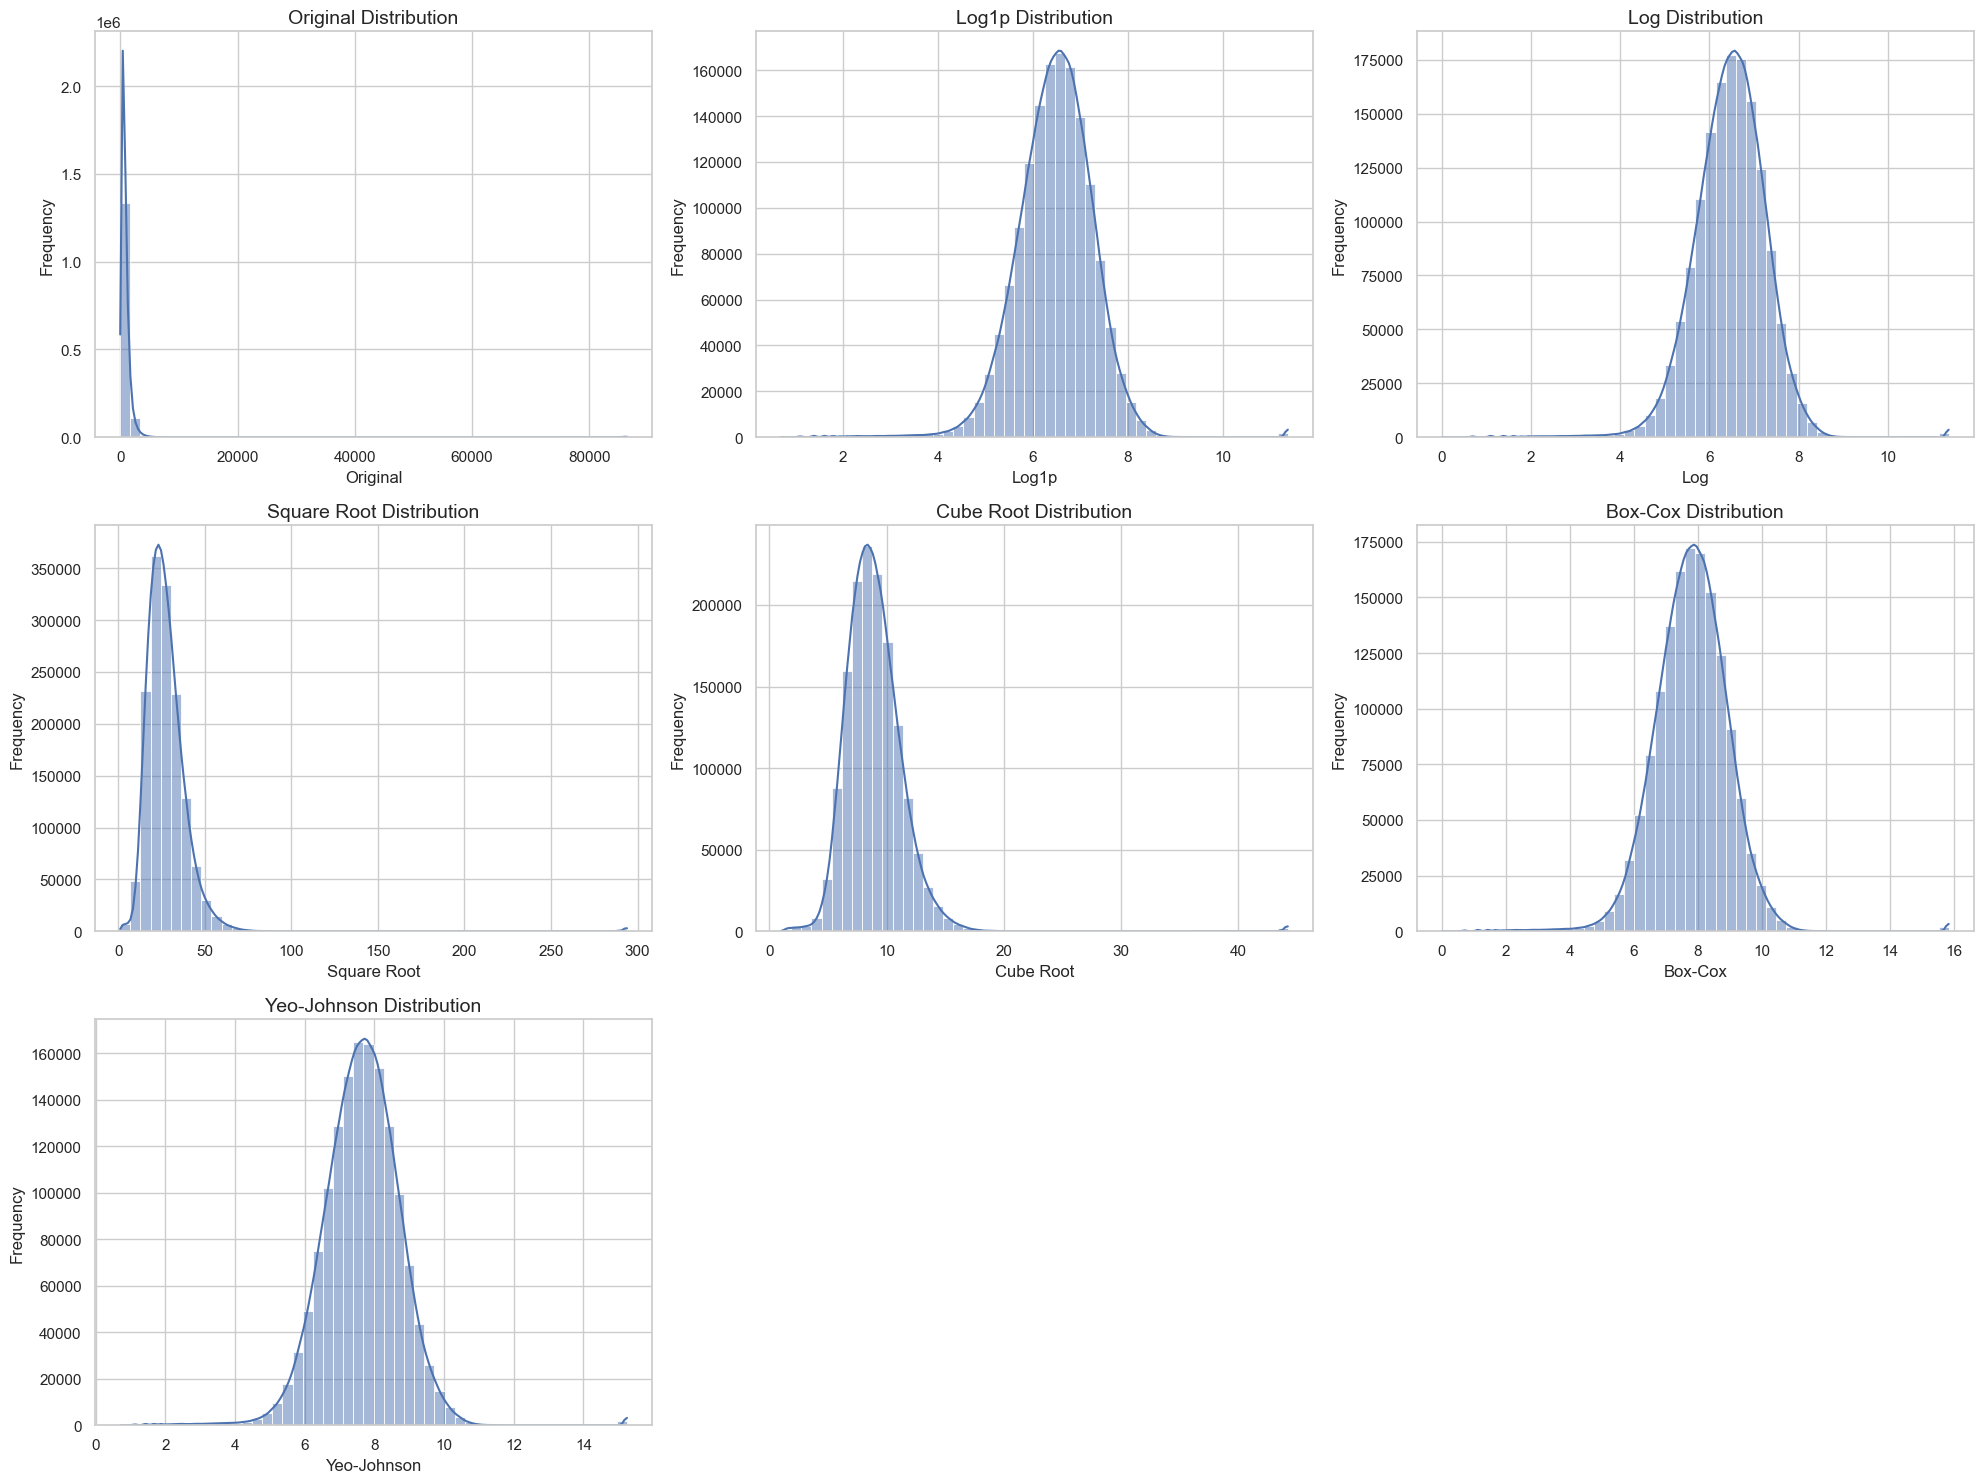

In [52]:
### 3.7.4 📊 Distribution Comparison of All Transformations

n_plots = len(transformations)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, (name, values) in enumerate(transformations.items()):
    sns.histplot(
        values,
        bins=50,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{name} Distribution")
    axes[i].set_xlabel(name)
    axes[i].set_ylabel("Frequency")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

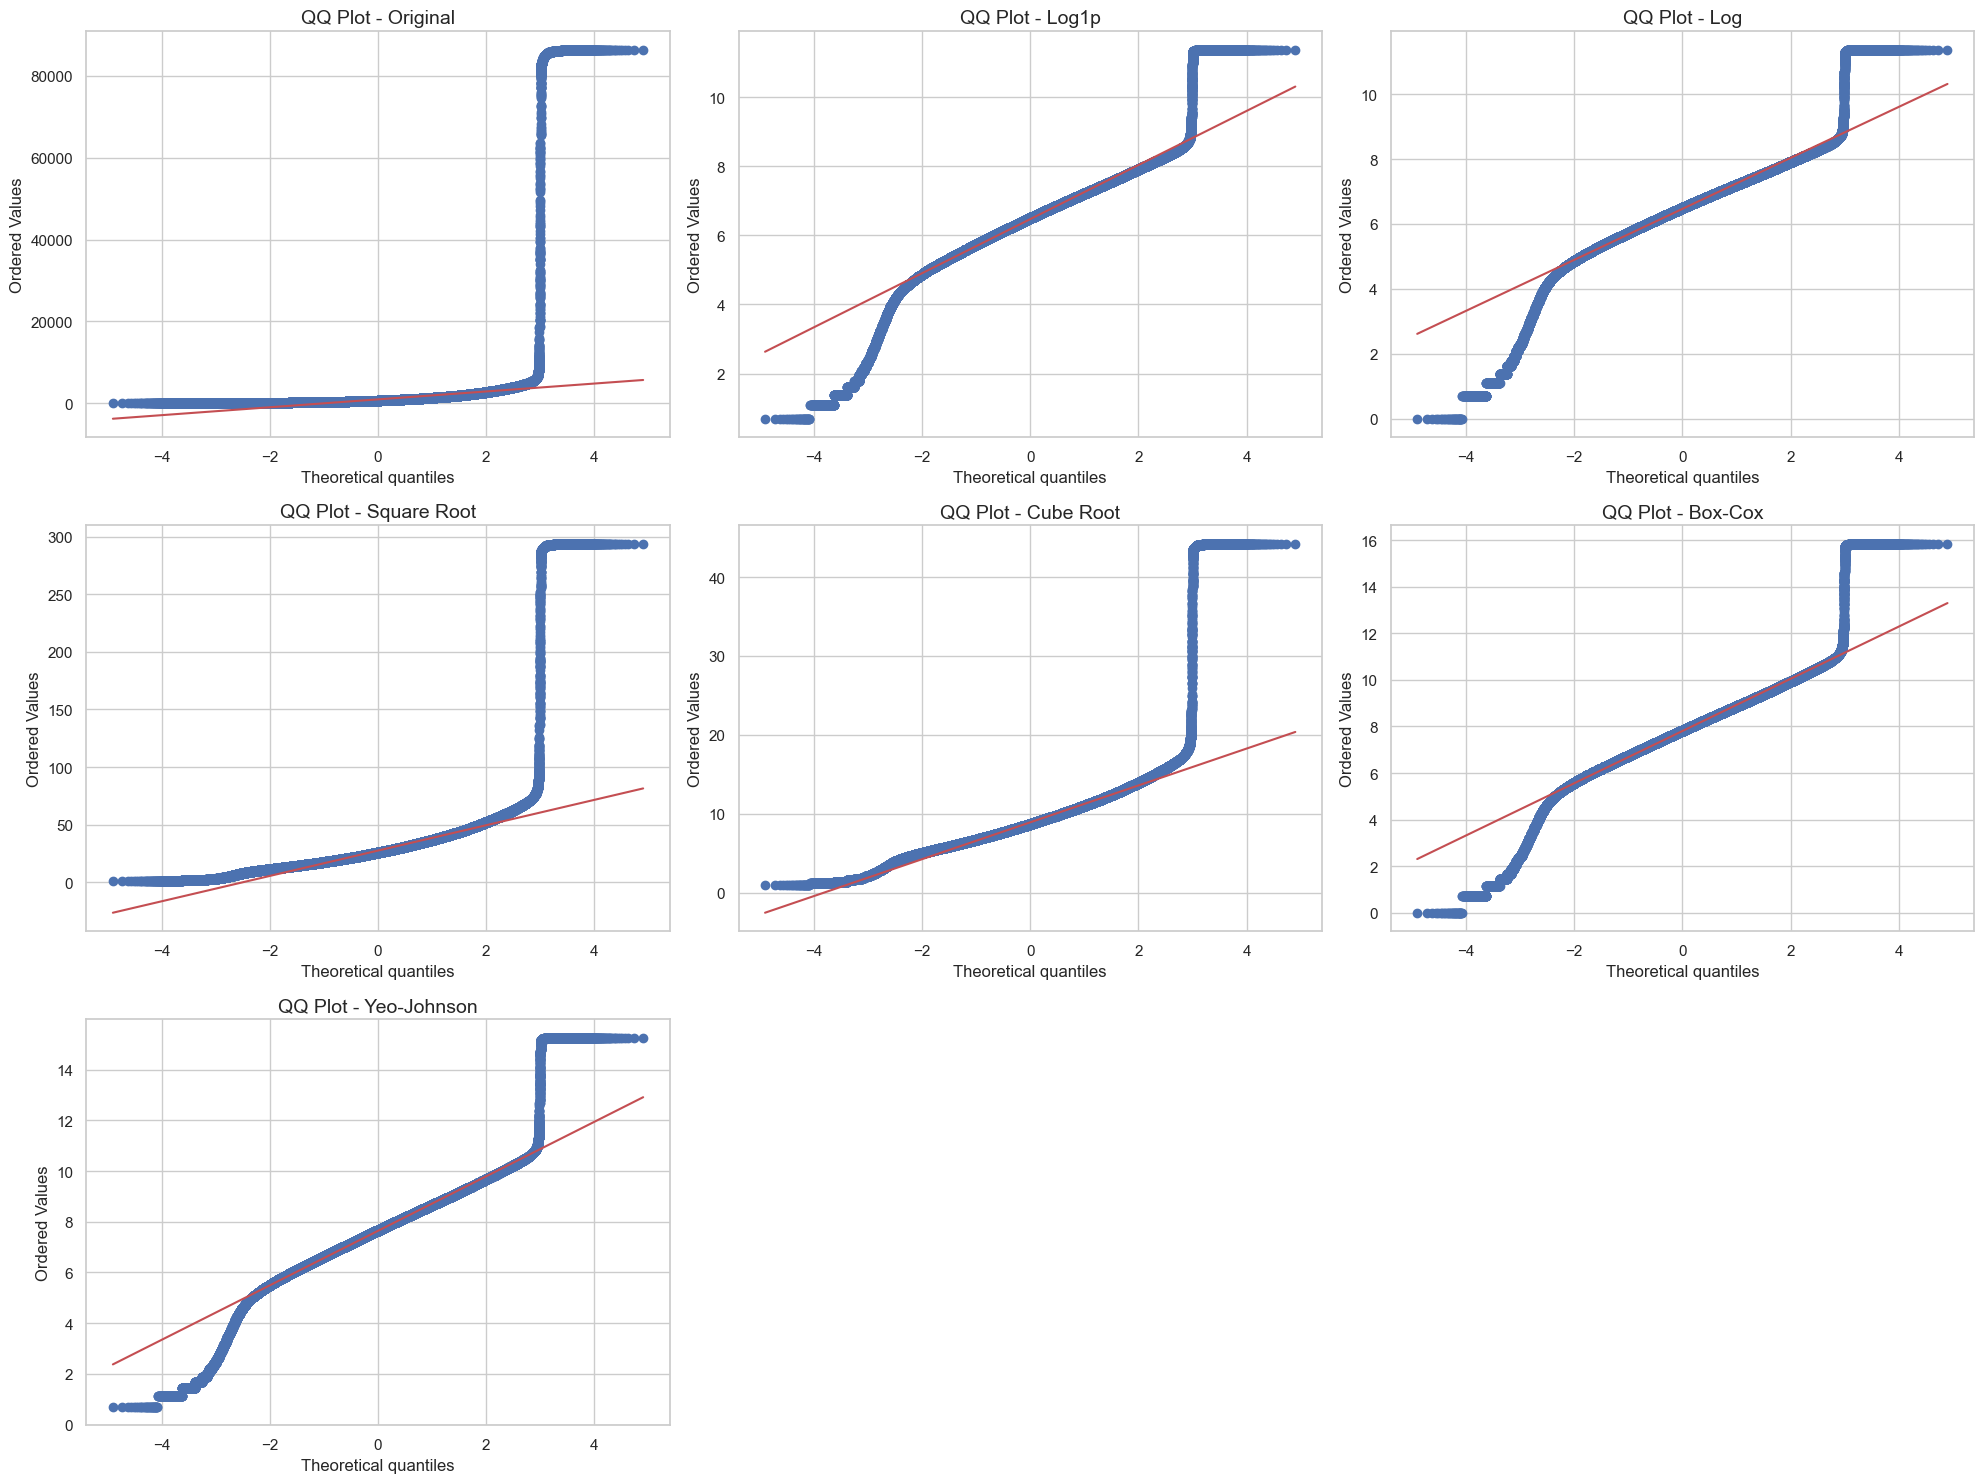

In [53]:
### 3.7.5 📈 QQ Plot Comparison of Transformations

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, (name, values) in enumerate(transformations.items()):
    stats.probplot(values, dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ Plot - {name}")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [54]:
### 3.7.6 🔝 Best Transformation Based on Skewness and Kurtosis

best_transformation = transformation_summary_df.iloc[0]

best_transformation_df = pd.DataFrame({
    "Metric": [
        "Best Transformation",
        "Skewness",
        "Kurtosis",
        "Shape Score"
    ],
    "Value": [
        best_transformation["Transformation"],
        round(best_transformation["Skewness"], 4),
        round(best_transformation["Kurtosis"], 4),
        round(best_transformation["Shape Score"], 4)
    ]
})

best_transformation_df

,Metric,Value
0,Best Transformation,Log1p
1,Skewness,-0.2932
2,Kurtosis,3.8320
3,Shape Score,4.1253


In [55]:
### 3.7.7 📊 Top 5 Transformations by Shape Score

top_transformations_df = transformation_summary_df[
    ["Transformation", "Skewness", "Kurtosis", "Shape Score"]
].head(5)

top_transformations_df.round(4)

,Transformation,Skewness,Kurtosis,Shape Score
0,Log1p,-0.2932,3.8320,4.1253
1,Yeo-Johnson,0.0523,4.1822,4.2345
2,Log,-0.3437,4.1477,4.4914
3,Box-Cox,0.0624,4.4301,4.4925
4,Cube Root,3.7428,46.5253,50.2680


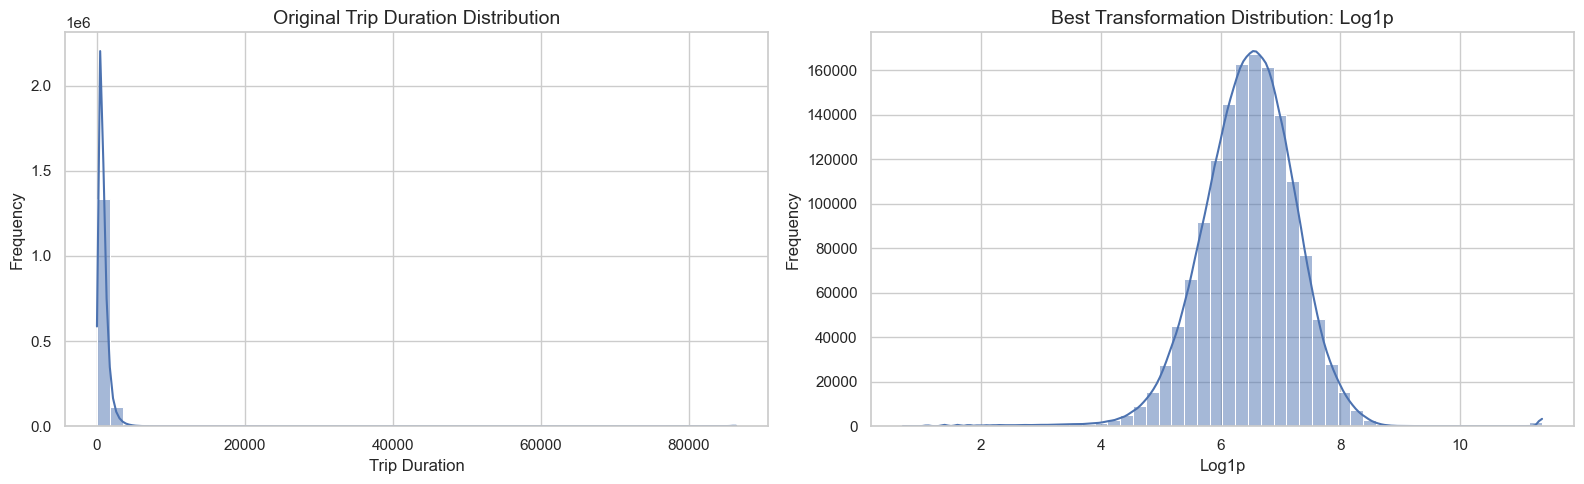

In [56]:
### 3.7.8 📌 Original vs Best Transformation Side-by-Side

best_name = best_transformation["Transformation"]
best_values = transformations[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    target_clean,
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Trip Duration Distribution")
axes[0].set_xlabel("Trip Duration")
axes[0].set_ylabel("Frequency")

sns.histplot(
    best_values,
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title(f"Best Transformation Distribution: {best_name}")
axes[1].set_xlabel(best_name)
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 📝 Summary of Target Transformation Analysis

- Different transformations were tested on `trip_duration`:  
  `Log1p`, `Log`, `Square Root`, `Cube Root`, `Box-Cox`, and `Yeo-Johnson`.

- The original `trip_duration` distribution is highly right-skewed and not normal-like.

- `Square Root` and `Cube Root` transformations improved the distribution slightly, but they still kept noticeable skewness and long-tail behavior.

- `Log1p`, `Log`, `Box-Cox`, and `Yeo-Johnson` made the distribution much more balanced compared to the original target.

- Based on the transformation comparison table, `Log1p` achieved the best overall shape score.

- `Log1p` transformation has:
  - Skewness: **-0.2932**
  - Kurtosis: **3.8320**
  - Shape Score: **4.1253**

- `Yeo-Johnson` and `Box-Cox` also performed well because their skewness values are close to zero.

- However, their kurtosis values are slightly higher than `Log1p`, so their overall shape scores are not better than `Log1p`.

- The QQ plots show that transformed versions fit the normal line much better than the original target.

- Still, the tails are not perfectly normal, which means some extreme duration patterns still exist.

- Overall, `Log1p` is the most practical and stable transformation for this target variable.

- For modeling, we can compare:
  - Raw target: `trip_duration`
  - Transformed target: `log1p(trip_duration)`

- The final target choice should be based on validation performance, not only EDA statistics.

# 4. 🧩 Feature Type Classification

In this section, we will manually classify each column based on its feature type.  
This step helps us decide how each feature should be handled during EDA, preprocessing, and feature engineering.

---

## 📌 Original Dataset Features

| Column Name | Feature Category | Sub-category | Notes |
|---|---|---|---|
| `id` | Identifier | Unique ID | Used only to identify each trip |
| `vendor_id` | Categorical | Nominal | Vendor label, not a true numeric value |
| `pickup_datetime` | Temporal | Datetime | Can be used for time-based feature extraction |
| `dropoff_datetime` | Temporal | Datetime / Leakage Risk | Useful for EDA, but should not be used in final model |
| `passenger_count` | Numeric | Count / Discrete | Number of passengers in the trip |
| `pickup_longitude` | Numeric | Continuous / Geospatial | Pickup location longitude |
| `pickup_latitude` | Numeric | Continuous / Geospatial | Pickup location latitude |
| `dropoff_longitude` | Numeric | Continuous / Geospatial | Dropoff location longitude |
| `dropoff_latitude` | Numeric | Continuous / Geospatial | Dropoff location latitude |
| `store_and_fwd_flag` | Categorical | Binary | Yes/No type flag |
| `trip_duration` | Target | Continuous Numeric | Prediction target |

---

## 🔢 Numeric Features

### 📏 Continuous Numeric Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`

### 👥 Count / Discrete Numeric Features
- `passenger_count`

### 🔢 Ordinal Numeric Features
- No direct ordinal numeric feature found

---

## 🏷️ Categorical Features

### 🧾 Nominal Categorical Features
- `vendor_id`

### 🔘 Binary Categorical Features
- `store_and_fwd_flag`

### 📊 Ordinal Categorical Features
- No direct ordinal categorical feature found

---

## ⏰ Temporal Features

### Original Datetime Features
- `pickup_datetime`
- `dropoff_datetime`

### Time Features Can Be Extracted From `pickup_datetime`
- `pickup_hour`
- `pickup_day`
- `pickup_month`
- `pickup_dayofweek`
- `pickup_weekday_name`
- `pickup_is_weekend`
- `pickup_minute`
- `pickup_time_of_day`

### Important Note
- `pickup_datetime` can be used for feature engineering.
- `dropoff_datetime` should be avoided in final modeling because it can create data leakage.

---

## 📍 Geospatial Features

### Original Location Features
- `pickup_longitude`
- `pickup_latitude`
- `dropoff_longitude`
- `dropoff_latitude`

### Possible Extracted Location Features
- `haversine_distance`
- `manhattan_distance`
- `pickup_cluster`
- `dropoff_cluster`
- `pickup_borough`
- `dropoff_borough`

---

## 🆔 Identifier Feature

- `id`

This feature is not useful for model learning because it only identifies each trip.

---

## 🎯 Target Feature

- `trip_duration`

This is the output variable we want to predict.  
It will not be used as an input feature.

---

## ✅ Feature Handling Decision

| Feature Type | Handling Plan |
|---|---|
| Identifier | Drop before modeling |
| Target | Separate as `y` |
| Continuous numeric | Check distribution, outliers, scaling need |
| Count numeric | Check invalid values and distribution |
| Nominal categorical | Encode properly |
| Binary categorical | Convert to 0/1 |
| Temporal | Extract useful time-based features |
| Geospatial | Create distance and location-based features |
| Leakage-risk feature | Avoid in final model |